# Week 6 (Tree-based Models)

## 2.1. Decision Tree

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [20]:
# 데이터 로드 및 전처리
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 훈련/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Q1.1 max_depth 파라미터를 변경하면 트리의 구조와 성능이 어떻게 변할까요?

`max_depth`가 작으면
    트리가 단순해져 해석이 쉽지만, 데이터의 패턴을 충분히 학습하지 못해 **과소적합**이 발생할 수 있다. 
 

`max_depth`가 크면
    깊이를 늘리면 분할과 리프 노드 수가 늘고 훈련 정확도는 일반적으로 높아지지만, 너무 깊으면 훈련 데이터의 잡음까지 학습하여 **과적합**이 발생할 수 있다. 


따라서 훈련과 테스트 성능을 함께 비교해 적절한 깊이를 선택해야 한다.

In [21]:
# max_depth별 트리 구조와 성능 비교
depth_results = []
for depth in [1, 2, 3, 4, 5, None]:
    model = DecisionTreeClassifier(
        criterion="gini", max_depth=depth, min_samples_leaf=2, random_state=42
    )
    model.fit(X_train, y_train)
    depth_results.append({
        "max_depth": str(depth),
        "actual_depth": model.get_depth(),
        "leaves": model.get_n_leaves(),
        "train_accuracy": model.score(X_train, y_train),
        "test_accuracy": model.score(X_test, y_test)
    })

depth_results_df = pd.DataFrame(depth_results)
display(depth_results_df.round(3))

# 이후 시각화에 사용할 최종 모델
tree_model = DecisionTreeClassifier(
    criterion="gini", max_depth=3, min_samples_leaf=2, random_state=42
)
tree_model.fit(X_train, y_train);


,max_depth,actual_depth,leaves,train_accuracy,test_accuracy
0,1,1,2,0.675,0.633
1,2,2,3,0.950,0.967
2,3,3,5,0.950,1.000
3,4,4,7,0.967,1.000
4,5,5,8,0.975,1.000
5,None,5,8,0.975,1.000


### Q1.2 'gini'와 'entropy' 기준의 차이는 무엇이며, 결과에 어떤 영향을 미칠까요?

- **Gini**

    $Gini = 1 - \sum_{k} p_k^2$

    한 노드에 여러 클래스가 섞여 있는 정도를 측정한다. 계산이 비교적 단순하고 빠르다.
- **Entropy**

    $Entropy = -\sum_{k} p_k \log_2 p_k$

    클래스 분포의 불확실성을 측정한다. 엔트로피가 가장 많이 감소하는 분할을 선택한다.

두 기준 모두 **분할 후 자식 노드의 가중 불순도를 가장 크게 감소시키는 특성과 임계값**을 선택한다. 따라서 대체로 비슷한 트리와 예측 성능을 만들지만, 불순도에 부여하는 값이 서로 달라 일부 노드의 분할 기준이나 최종 트리 구조가 달라질 수 있다. 일반적으로 entropy는 gini보다 계산량이 조금 많지만, 정확도 차이는 크지 않으므로 교차 검증 결과를 바탕으로 선택하는 것이 좋다.

### Q1.3 각 노드의 분할 기준 어떻게 되는지 설명해보세요.

각 노드에서는 모든 특성과 가능한 임계값을 비교하여, **분할 후 자식 노드의 가중 Gini 불순도를 가장 크게 줄이는 조건**을 선택한다. 조건을 만족하면 왼쪽, 만족하지 않으면 오른쪽 자식 노드로 이동한다.

현재 모델의 주요 분할은 다음과 같다.

1. `petal length (cm) <= 2.45`: 조건을 만족하는 경우 setosa로 분류한다.
2. 나머지 샘플은 `petal length (cm) <= 4.75`로 다시 나눈다.
3. 하위 노드에서 `petal width (cm) <= 1.55` 또는 `<= 1.75`를 이용해 versicolor와 virginica를 구분한다.

트리 그림의 `gini`는 클래스가 섞인 정도, `samples`는 해당 노드에 도달한 훈련 샘플 수, `value`는 클래스별 샘플 수, `class`는 해당 노드의 최종 예측 클래스를 의미한다.

In [22]:
# 트리 시각화 (Graphviz)
dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)

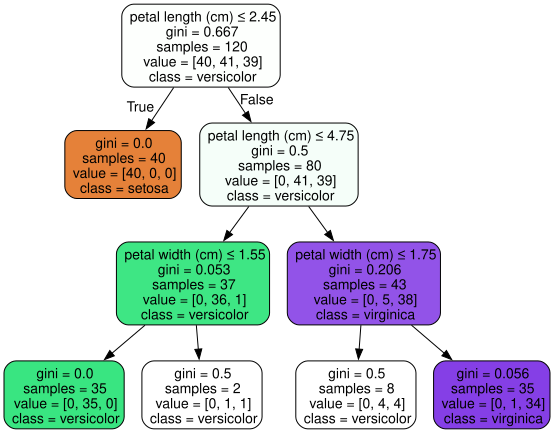

In [23]:
# 그래프 출력
graph = graphviz.Source(dot_data)
graph

## 3. 앙상블 학습: 부스팅(Boosting) 모델

Adaboost, Gradient Boosting Model은 scikit learn에서 지원하지만, LightGBM과 XGBoost의 경우는 외부 패키지를 불러와야 합니다.

Boosting 계열의 모델들은 데이터 개수가 적으면 overfitting이 일어나는 경우가 많으니, 주의해야 합니다.

In [24]:
# 필요한 패키지 로드
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error

housing = fetch_california_housing()

In [25]:
# 데이터 로드
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['MedHouseVal'] = housing.target

In [26]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Q3.1 `housing_df`를 train, test split을 해봅시다.

분할 비율을 자유롭게 설정해봅시다.

In [27]:
# 데이터 분할
X = housing_df.drop(columns=['MedHouseVal'])
y = housing_df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train set:", X_train.shape, y_train.shape)
print("Test set :", X_test.shape, y_test.shape)

Train set: (16512, 8) (16512,)
Test set : (4128, 8) (4128,)


### Q3.2  데이터를 `RandomForestRegressor`에 적합해 봅시다.
train set 에 대해 `MedHouseVal`을 종속변수, 나머지를 독립변수로 하는 random forest regressor를 적합해 봅시다.

test set으로 prediction을 한 후 MSE를 구해 봅시다.

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
print(f"Random Forest MSE: {rf_mse:.4f}")

Random Forest MSE: 0.2539


### Q3.3 데이터를 `AdaBoostRegressor`에 적합해봅시다.

위와 동일

In [29]:
from sklearn.ensemble import AdaBoostRegressor

ada_model = AdaBoostRegressor(
    n_estimators=200, learning_rate=0.05, loss="linear", random_state=42
)
ada_model.fit(X_train, y_train)
ada_pred = ada_model.predict(X_test)
ada_mse = mean_squared_error(y_test, ada_pred)
print(f"AdaBoost MSE: {ada_mse:.4f}")

AdaBoost MSE: 0.5732


### Q3.4 데이터를 `GradientBoostingRegressor`에 적합해 봅시다.

위와 동일

In [30]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_pred)
print(f"Gradient Boosting MSE: {gb_mse:.4f}")

Gradient Boosting MSE: 0.2912


### Q3.5 데이터를 `lightgbm` 회귀에 적합해 봅시다.

파라미터를 자세히 살펴보고, 자유롭게 설정해 봅시다.

Documentation
https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

예시
https://www.geeksforgeeks.org/regression-using-lightgbm/


In [31]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test)
lgb_mse = mean_squared_error(y_test, lgb_pred)
print(f"LightGBM MSE: {lgb_mse:.4f}")

LightGBM MSE: 0.1920


### Q3.6 데이터를 `xgboost`에 적합해 봅시다.

파라미터는 자유롭게 설정해 봅시다

In [32]:
# 미설치 시 먼저 실행: %pip install xgboost
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_mse = mean_squared_error(y_test, xgb_pred)
print(f"XGBoost MSE: {xgb_mse:.4f}")

XGBoost MSE: 0.1979


### Q3.7 `RandomForestRegressor`의 feature importance를 시각화해봅시다.

https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

위를 참고해보면서 Q2에서 적합한 random forest regressor의 feature importance를 시각화해 봅시다.

중요한 feature 부터 내림차순으로 시각화해 봅시다.

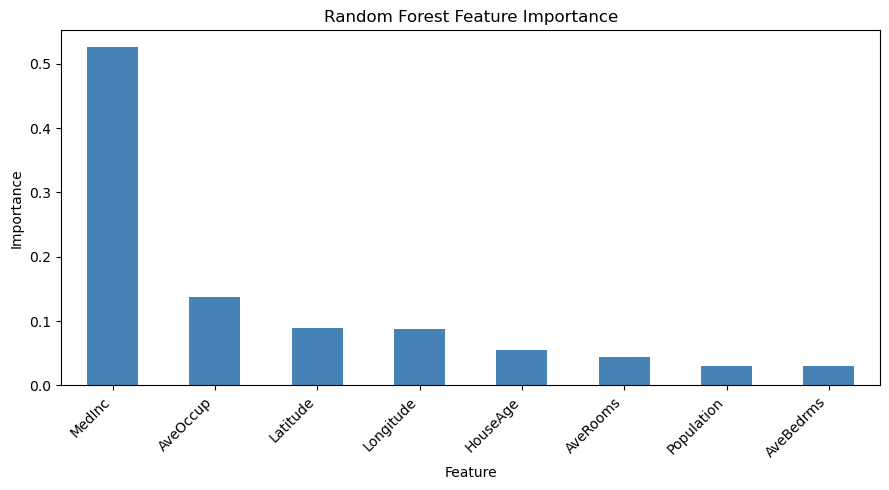

,importance
MedInc,0.525916
AveOccup,0.138125
Latitude,0.088588
Longitude,0.088338
HouseAge,0.054342
AveRooms,0.044394
Population,0.030637
AveBedrms,0.029659


In [33]:
# Random Forest feature importance를 내림차순으로 시각화
feature_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns, name="importance"
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feature_importance.plot(kind="bar", color="steelblue")
plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

feature_importance.to_frame()

### (BONUS) 1. Boosting 모델 각각의 특징을 정리해보세요.

- **AdaBoost**: 앞선 모델이 틀린 샘플에 더 큰 가중치를 부여하며 약한 학습기를 순차적으로 학습한다. 구현이 간단하지만 이상치와 잡음에 민감할 수 있다.
- **Gradient Boosting**: 이전 모델의 오차, 즉 손실함수의 음의 그라디언트를 다음 모델이 보정하도록 순차적으로 학습한다. 성능은 좋지만 학습이 느릴 수 있고 하이퍼파라미터에 민감하다.
- **LightGBM**: 히스토그램 기반의 leaf-wise 트리 성장 방식을 사용해 대규모 데이터에서 학습 속도가 빠르고 메모리 효율이 높다. 데이터가 작을 때는 과적합에 주의해야 한다.
- **XGBoost**: Gradient Boosting에 규제화, 결측치 처리, 병렬 연산 등을 추가해 성능과 안정성을 높인 모델이다. 예측 성능이 좋지만 조절할 파라미터가 많고 상대적으로 학습 비용이 크다.

### (BONUS) 2. 모델 성능을 높이기 위하여 어떤 시도를 하면 좋을지 고민해보세요.

1. **교차 검증과 하이퍼파라미터 튜닝**: `GridSearchCV` 또는 `RandomizedSearchCV`로 `n_estimators`, `max_depth`, `learning_rate`, `num_leaves`, `subsample` 등을 탐색한다.
2. **과적합 제어**: 트리 깊이를 제한하고, 샘플링과 규제화를 사용하며, Boosting 모델은 검증 세트를 이용한 early stopping을 적용한다.
3. **데이터 개선**: 이상치를 점검하고, 유용한 파생 특성을 추가하며, 중요도가 매우 낮거나 잡음이 큰 특성을 정리한다.
4. **올바른 평가**: 여러 교차 검증 폴드의 MSE를 비교하고, RMSE와 MAE도 함께 확인해 특정 분할에서만 성능이 좋은지 점검한다.
5. **앙상블 비교**: 단일 모델을 가정하지 말고 Random Forest, Gradient Boosting, LightGBM, XGBoost의 검증 성능을 비교해 가장 잘 일반화되는 모델을 선택한다.

## 이건 추가적인 궁금증입니다!

트리 모델은 매 분할 스텝마다 '현재 노드의 불순도를 가장 크게 낮추는 특성과 임계점'을 선택하는 것으로 알고 있습니다. 이는 매 순간 당장의 최적해를 찾는다는 점에서 '그리디 알고리즘(Greedy Algorithm)'과 매우 유사해 보입니다.


하지만 그리디 알고리즘의 한계처럼, 매 순간의 부분적인 최선의 선택(Local Optimum)이 최종 모델의 전체적인 최적 결과(Global Optimum)를 보장하지는 않을 것 같다는 의문이 들었습니다.


실제로 트리 모델에서 이러한 탐욕적 탐색 방식이 최선의 최종 결과로 이어지는지, 만약 한계가 존재한다면 모델링 과정에서 이를 어떤 방식으로 극복하고 있는지 궁금합니다